# EDA and Machine Learning on Agricultural Yield Dataset

This notebook generates a synthetic agricultural dataset (so it runs standalone, no upload needed) and answers all questions Q1–Q14.

If you have your own real dataset CSV instead, skip the "Generate Dataset" cell and replace it with:
```python
df = pd.read_csv('your_file.csv')
```
just make sure the column names match: `crop_type, soil_type, rainfall_mm, temperature_c, fertilizer_kg, yield_ton_per_hectare`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
np.random.seed(42)

## Generate Dataset (synthetic, standalone)

In [2]:
n = 500

crop_types = ['Wheat', 'Rice', 'Maize', 'Sugarcane', 'Cotton']
soil_types = ['Loamy', 'Clay', 'Sandy', 'Silty']

crop_type = np.random.choice(crop_types, size=n, p=[0.30, 0.25, 0.20, 0.15, 0.10])
soil_type = np.random.choice(soil_types, size=n, p=[0.40, 0.25, 0.20, 0.15])

rainfall_mm = np.clip(np.random.normal(900, 150, n), 200, 1600)
temperature_c = np.clip(np.random.normal(27, 4, n), 15, 40)
fertilizer_kg = np.clip(np.random.normal(120, 30, n), 20, 250)

yield_ton_per_hectare = (
    0.0025 * rainfall_mm
    + 0.015 * fertilizer_kg
    - 0.02 * (temperature_c - 27) ** 2
    + np.random.normal(0, 0.5, n)
)
yield_ton_per_hectare = np.clip(yield_ton_per_hectare, 0.5, None)

df = pd.DataFrame({
    'crop_type': crop_type,
    'soil_type': soil_type,
    'rainfall_mm': rainfall_mm.round(2),
    'temperature_c': temperature_c.round(2),
    'fertilizer_kg': fertilizer_kg.round(2),
    'yield_ton_per_hectare': yield_ton_per_hectare.round(2)
})

df.to_csv('agricultural_yield.csv', index=False)
df.head()

,crop_type,soil_type,rainfall_mm,temperature_c,fertilizer_kg,yield_ton_per_hectare
0,Rice,Sandy,926.66,27.53,77.81,2.62
1,Cotton,Clay,699.70,26.39,117.51,3.17
2,Maize,Loamy,957.03,29.83,74.86,3.95
3,Maize,Sandy,991.59,30.83,142.80,3.84
4,Wheat,Sandy,983.97,23.86,122.47,3.87


## Part A: Understanding the Dataset

### Q1. Dataset Overview

In [3]:
print("Rows, Columns:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nFirst 10 records:")
df.head(10)

Rows, Columns: (500, 6)

Column names: ['crop_type', 'soil_type', 'rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

First 10 records:


,crop_type,soil_type,rainfall_mm,temperature_c,fertilizer_kg,yield_ton_per_hectare
0,Rice,Sandy,926.66,27.53,77.81,2.62
1,Cotton,Clay,699.70,26.39,117.51,3.17
2,Maize,Loamy,957.03,29.83,74.86,3.95
3,Maize,Sandy,991.59,30.83,142.80,3.84
4,Wheat,Sandy,983.97,23.86,122.47,3.87
5,Wheat,Loamy,1062.12,21.68,76.27,3.46
6,Wheat,Silty,1025.09,19.66,110.72,3.54
7,Sugarcane,Sandy,968.88,29.03,97.44,3.68
8,Maize,Silty,889.48,22.59,129.58,3.48
9,Maize,Sandy,650.86,18.39,160.21,3.26


### Q2. Data Types and Missing Values

In [4]:
print("Data types:\n", df.dtypes)

missing = df.isnull().sum()
print("\nMissing values per column:\n", missing)

missing_cols = missing[missing > 0].index.tolist()
if missing_cols:
    print("\nColumns with missing values:", missing_cols)
else:
    print("\nNo missing values present in the dataset.")

Data types:
 crop_type                 object
soil_type                 object
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
yield_ton_per_hectare    float64
dtype: object

Missing values per column:
 crop_type                0
soil_type                0
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
yield_ton_per_hectare    0
dtype: int64

No missing values present in the dataset.


### Q3. Descriptive Statistics

In [5]:
desc = df.describe()
print(desc)

highest_mean_feature = desc.loc['mean'].idxmax()
highest_std_feature = desc.loc['std'].idxmax()

print(f"\nFeature with highest mean value: {highest_mean_feature} ({desc.loc['mean', highest_mean_feature]:.2f})")
print(f"Feature with highest standard deviation: {highest_std_feature} ({desc.loc['std', highest_std_feature]:.2f})")

       rainfall_mm  temperature_c  fertilizer_kg  yield_ton_per_hectare
count   500.000000     500.000000     500.000000             500.000000
mean    917.526980      27.323680     119.028400               3.791280
std     147.596363       3.978002      29.291497               0.865787
min     465.560000      15.310000      29.410000               1.030000
25%     816.710000      24.650000     100.515000               3.287500
50%     919.030000      27.240000     119.325000               3.880000
75%    1010.410000      29.962500     138.767500               4.380000
max    1286.960000      39.770000     214.130000               6.060000

Feature with highest mean value: rainfall_mm (917.53)
Feature with highest standard deviation: rainfall_mm (147.60)


## Part B: Exploratory Data Analysis (EDA)

### Q4. Distribution Analysis

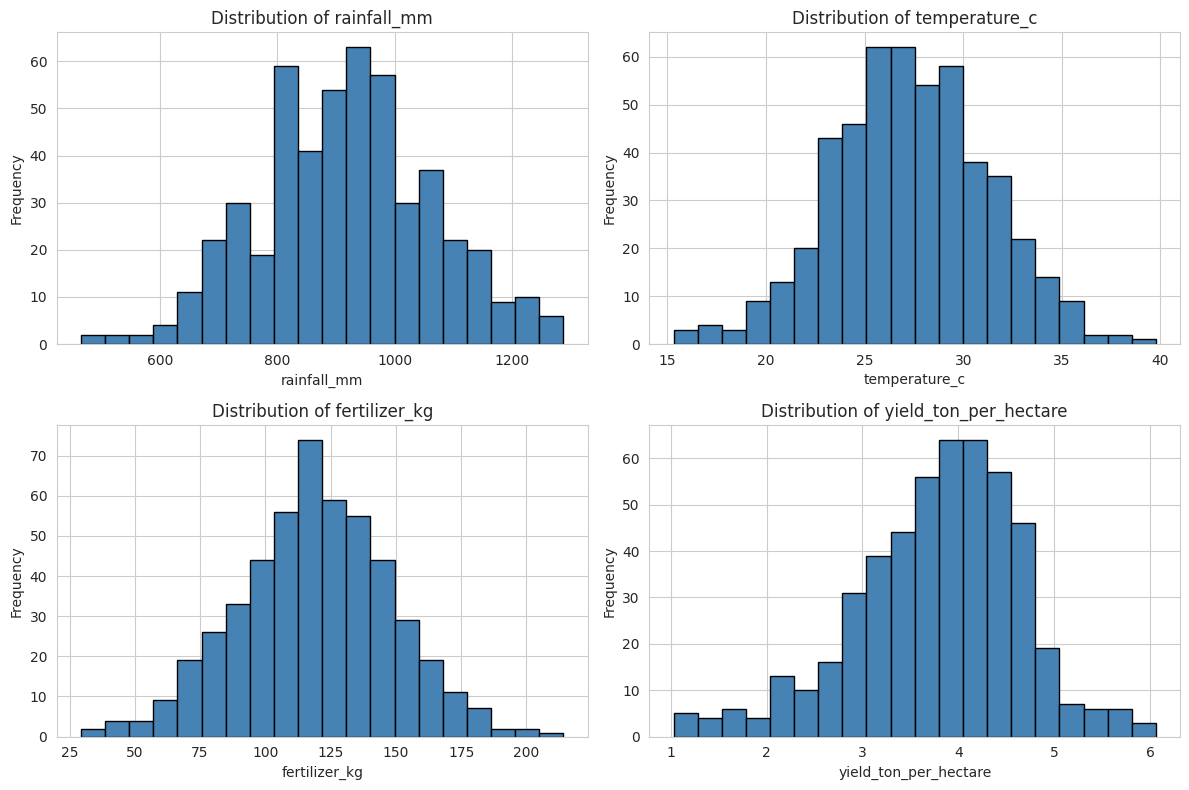

In [6]:
cols_to_plot = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [7]:
def observations(col):
    skew = df[col].skew()
    shape = "approximately symmetric" if abs(skew) < 0.5 else ("right-skewed" if skew > 0 else "left-skewed")
    mean_median_gap = abs(df[col].mean() - df[col].median())
    closeness = "close together" if mean_median_gap < 0.1 * df[col].std() else "noticeably apart"
    return [
        f"Shape: {shape} (skewness = {skew:.2f}).",
        f"Mean ({df[col].mean():.2f}) and median ({df[col].median():.2f}) are {closeness}.",
        f"Spread: ranges from {df[col].min():.2f} to {df[col].max():.2f}, std = {df[col].std():.2f}."
    ]

for col in cols_to_plot:
    print(f"Observations — {col}:")
    for point in observations(col):
        print(" -", point)
    print()

Observations — rainfall_mm:
 - Shape: approximately symmetric (skewness = -0.01).
 - Mean (917.53) and median (919.03) are close together.
 - Spread: ranges from 465.56 to 1286.96, std = 147.60.

Observations — temperature_c:
 - Shape: approximately symmetric (skewness = -0.06).
 - Mean (27.32) and median (27.24) are close together.
 - Spread: ranges from 15.31 to 39.77, std = 3.98.

Observations — fertilizer_kg:
 - Shape: approximately symmetric (skewness = -0.06).
 - Mean (119.03) and median (119.33) are close together.
 - Spread: ranges from 29.41 to 214.13, std = 29.29.

Observations — yield_ton_per_hectare:
 - Shape: left-skewed (skewness = -0.53).
 - Mean (3.79) and median (3.88) are noticeably apart.
 - Spread: ranges from 1.03 to 6.06, std = 0.87.



### Q5. Crop Type Analysis

crop_type
Wheat        154
Rice         118
Maize         97
Sugarcane     76
Cotton        55
Name: count, dtype: int64


/tmp/ipykernel_614/2442326664.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')


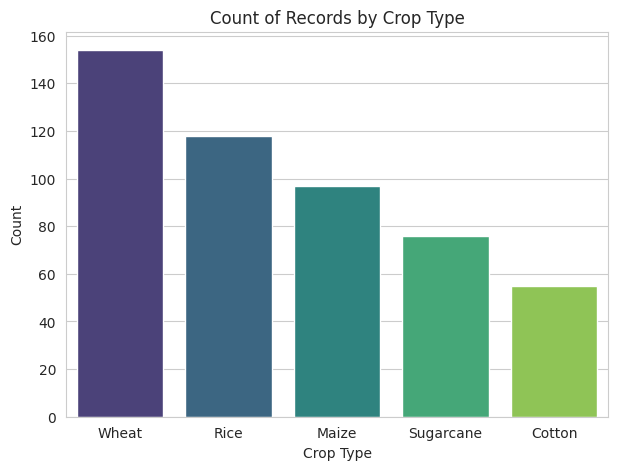


Most frequent crop type: Wheat (154 records)


In [8]:
crop_counts = df['crop_type'].value_counts()
print(crop_counts)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')
plt.title('Count of Records by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.show()

print(f"\nMost frequent crop type: {crop_counts.idxmax()} ({crop_counts.max()} records)")

### Q6. Soil Type Analysis

soil_type
Loamy    214
Clay     130
Sandy     86
Silty     70
Name: count, dtype: int64


/tmp/ipykernel_614/2003003201.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')


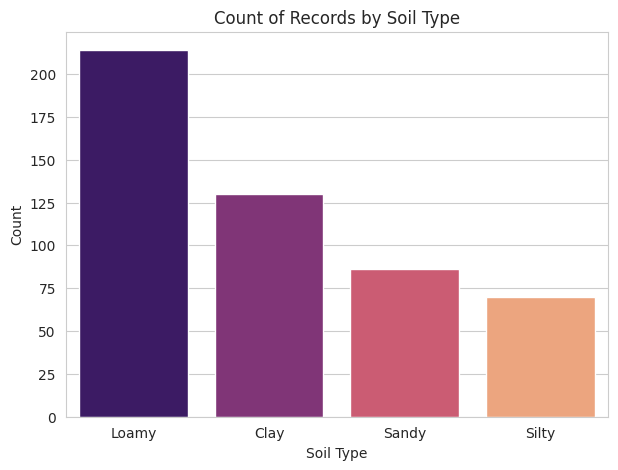


Most common soil type: Loamy (214 records)


In [9]:
soil_counts = df['soil_type'].value_counts()
print(soil_counts)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')
plt.title('Count of Records by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.show()

print(f"\nMost common soil type: {soil_counts.idxmax()} ({soil_counts.max()} records)")

### Q7. Yield Distribution

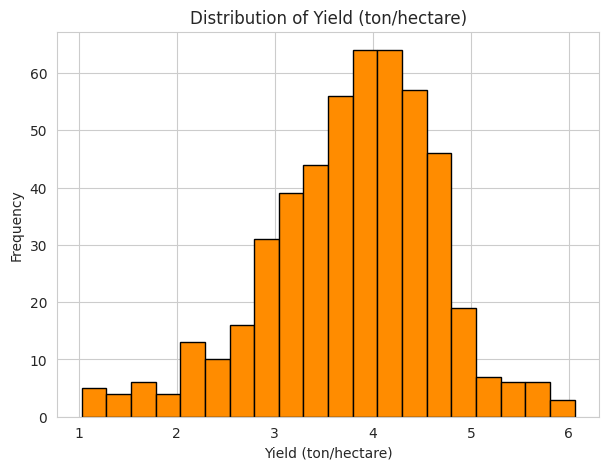

Skewness: -0.53
Shapiro-Wilk test: stat=0.9788, p-value=0.0000
=> Distribution deviates from normal (reject normality at 5% significance).

Outliers detected (IQR method): 13


In [10]:
plt.figure(figsize=(7, 5))
plt.hist(df['yield_ton_per_hectare'], bins=20, color='darkorange', edgecolor='black')
plt.title('Distribution of Yield (ton/hectare)')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.show()

skew_val = df['yield_ton_per_hectare'].skew()
shapiro_stat, shapiro_p = stats.shapiro(df['yield_ton_per_hectare'])

print(f"Skewness: {skew_val:.2f}")
print(f"Shapiro-Wilk test: stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("=> Distribution is approximately normal (fail to reject normality at 5% significance).")
else:
    print("=> Distribution deviates from normal (reject normality at 5% significance).")

Q1_, Q3_ = df['yield_ton_per_hectare'].quantile([0.25, 0.75])
IQR = Q3_ - Q1_
lower, upper = Q1_ - 1.5 * IQR, Q3_ + 1.5 * IQR
outliers = df[(df['yield_ton_per_hectare'] < lower) | (df['yield_ton_per_hectare'] > upper)]
print(f"\nOutliers detected (IQR method): {len(outliers)}")

### Q8. Scatter Plot Analysis

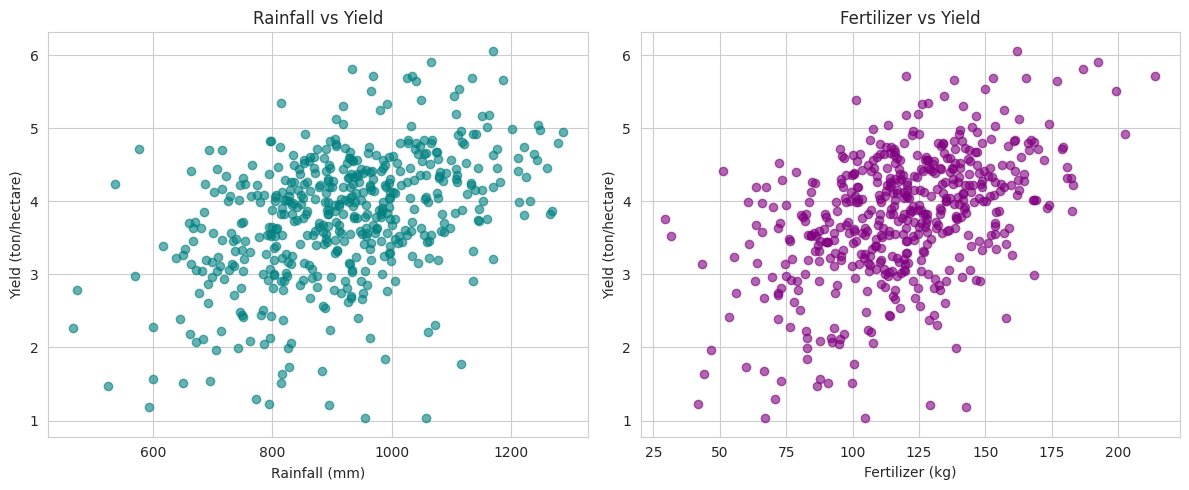

Correlation — Rainfall vs Yield: 0.435
Correlation — Fertilizer vs Yield: 0.475

=> fertilizer_kg shows the stronger relationship with yield.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['rainfall_mm'], df['yield_ton_per_hectare'], alpha=0.6, color='teal')
axes[0].set_title('Rainfall vs Yield')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Yield (ton/hectare)')

axes[1].scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'], alpha=0.6, color='purple')
axes[1].set_title('Fertilizer vs Yield')
axes[1].set_xlabel('Fertilizer (kg)')
axes[1].set_ylabel('Yield (ton/hectare)')

plt.tight_layout()
plt.show()

corr_rain = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
corr_fert = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])

print(f"Correlation — Rainfall vs Yield: {corr_rain:.3f}")
print(f"Correlation — Fertilizer vs Yield: {corr_fert:.3f}")

stronger = 'rainfall_mm' if abs(corr_rain) > abs(corr_fert) else 'fertilizer_kg'
print(f"\n=> {stronger} shows the stronger relationship with yield.")

### Q9. Correlation Analysis

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000      -0.020851      -0.010741   
temperature_c            -0.020851       1.000000      -0.001331   
fertilizer_kg            -0.010741      -0.001331       1.000000   
yield_ton_per_hectare     0.434906      -0.062405       0.474793   

                       yield_ton_per_hectare  
rainfall_mm                         0.434906  
temperature_c                      -0.062405  
fertilizer_kg                       0.474793  
yield_ton_per_hectare               1.000000  


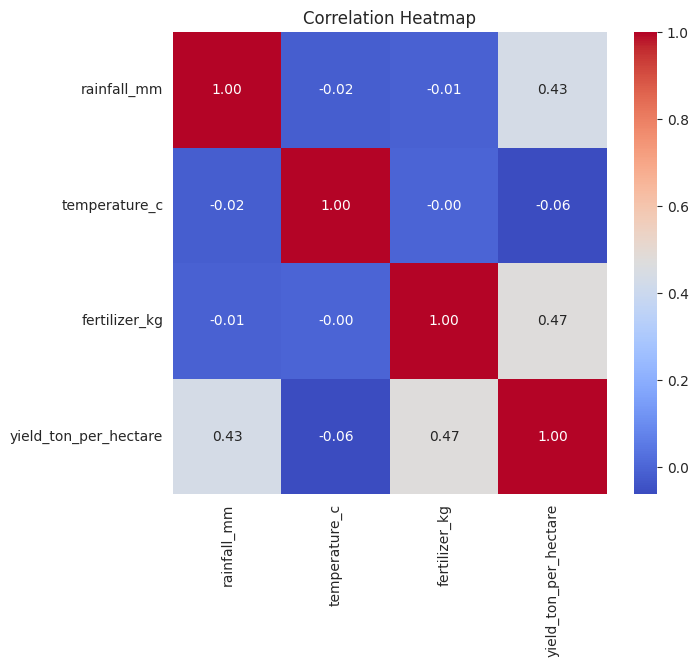


Top 3 features most correlated with yield:
fertilizer_kg    0.474793
rainfall_mm      0.434906
temperature_c    0.062405
Name: yield_ton_per_hectare, dtype: float64


In [12]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print(corr_matrix)

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

target_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').abs().sort_values(ascending=False)
print("\nTop 3 features most correlated with yield:")
print(target_corr.head(3))

### Q10. Group-Based Analysis

In [13]:
avg_yield_by_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
avg_yield_by_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)

print("Average yield by crop type:\n", avg_yield_by_crop)
print("\nAverage yield by soil type:\n", avg_yield_by_soil)

print(f"\nCrop with highest average yield: {avg_yield_by_crop.idxmax()} ({avg_yield_by_crop.max():.2f})")
print(f"Soil type with highest average yield: {avg_yield_by_soil.idxmax()} ({avg_yield_by_soil.max():.2f})")

Average yield by crop type:
 crop_type
Cotton       3.859636
Wheat        3.847727
Maize        3.752474
Rice         3.747288
Sugarcane    3.745263
Name: yield_ton_per_hectare, dtype: float64

Average yield by soil type:
 soil_type
Silty    3.953714
Sandy    3.826744
Loamy    3.769533
Clay     3.716154
Name: yield_ton_per_hectare, dtype: float64

Crop with highest average yield: Cotton (3.86)
Soil type with highest average yield: Silty (3.95)


## Part C: Data Preparation

### Q11. Feature Encoding

In [14]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nTransformed dataset (first 5 rows):")
df_encoded.head()

Categorical columns: ['crop_type', 'soil_type']

Transformed dataset (first 5 rows):


,rainfall_mm,temperature_c,fertilizer_kg,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Sugarcane,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy,soil_type_Silty
0,926.66,27.53,77.81,2.62,False,True,False,False,False,True,False
1,699.70,26.39,117.51,3.17,False,False,False,False,False,False,False
2,957.03,29.83,74.86,3.95,True,False,False,False,True,False,False
3,991.59,30.83,142.80,3.84,True,False,False,False,False,True,False
4,983.97,23.86,122.47,3.87,False,False,False,True,False,True,False


### Q12. Feature Selection

In [15]:
target_col = 'yield_ton_per_hectare'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print(f"Target variable: {target_col}")
print(f"Input features shape: {X.shape}")
print("Input feature columns:", list(X.columns))

Target variable: yield_ton_per_hectare
Input features shape: (500, 10)
Input feature columns: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Sugarcane', 'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy', 'soil_type_Silty']


## Part D: Machine Learning

### Q13. Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (400, 10)
X_test shape: (100, 10)
y_train shape: (400,)
y_test shape: (100,)


### Q14. Linear Regression Model

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

coef_series = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print("Model coefficients:\n", coef_series)
print(f"\nIntercept: {model.intercept_:.4f}")
print(f"\nFeature with highest positive coefficient: {coef_series.idxmax()} ({coef_series.max():.4f})")

y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"\nModel performance on test set — R²: {r2_score(y_test, y_pred):.4f}, RMSE: {rmse:.4f}")

Model coefficients:
 soil_type_Silty        0.081902
crop_type_Rice         0.064759
soil_type_Loamy        0.030448
fertilizer_kg          0.013419
rainfall_mm            0.002649
temperature_c         -0.006741
soil_type_Sandy       -0.018460
crop_type_Sugarcane   -0.043652
crop_type_Wheat       -0.043880
crop_type_Maize       -0.114426
dtype: float64

Intercept: -0.0469

Feature with highest positive coefficient: soil_type_Silty (0.0819)

Model performance on test set — R²: 0.4614, RMSE: 0.6463
